# Proyek Analisis Data: E-commerce Public Dataset
- **Nama:** Favian Indrafatta
- **Email:** 23400016.favian@tsu.ac.id
- **ID Dicoding:** CDCC899D6Y2696

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana pengaruh harga produk terhadap jumlah pembelian, serta seberapa besar sensitivitas pelanggan terhadap harga?
- **Pertanyaan 2:** Produk atau kategori produk apa yang cenderung mendapatkan review rendah, dan faktor apa saja yang memengaruhi kepuasan pelanggan?

## Import Semua Packages/Library yang Digunakan

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression


## Data Wrangling

### Gathering Data

In [122]:
orders = pd.read_csv('/content/data_1.csv')
orders_item = pd.read_csv('/content/data_2.csv')
products = pd.read_csv('/content/data_3.csv')
reviews = pd.read_csv('/content/data_4.csv')

orders.head()
orders_item.head()
products.head()
reviews.head()


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:** (Opsional)
- data dari beberapa tabel seperti orders, order_items, products, dan reviews berhasil digabungkan menjadi satu dataset yang terintegrasi. Proses pembersihan dilakukan dengan menghapus data duplikat dan nilai yang tidak valid sehingga kualitas data menjadi lebih baik dan siap untuk dianalisis.


### Assessing Data

In [123]:
orders_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [124]:
orders_item.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [125]:
reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


**Insight:** (Opsional)
- Berdasarkan hasil pemeriksaan data pada tabel order_items, terdapat 112.650 baris data dengan 7 kolom, dan seluruh kolom tidak memiliki nilai kosong. Tipe data yang digunakan juga sudah sesuai, yaitu numerik untuk harga dan biaya pengiriman, serta tipe objek untuk data identitas. Hal ini menunjukkan bahwa dataset order_items dalam kondisi baik dan siap digunakan untuk analisis lebih lanjut tanpa perlu penanganan missing value.

- Pada tabel reviews, sebagian besar kolom juga tidak memiliki nilai kosong, kecuali pada kolom review_comment_title dan review_comment_message yang memiliki banyak missing value. Namun, hal ini masih wajar karena tidak semua pelanggan memberikan komentar tertulis, meskipun tetap memberikan skor penilaian. Oleh karena itu, analisis tetap dapat difokuskan pada kolom review_score sebagai indikator utama kepuasan pelanggan.

### Cleaning Data

#### Fixing ... problem

In [126]:
order_items = orders_item.dropna()
order_items = order_items.drop_duplicates()
order_items = order_items[order_items['price'] > 0]

reviews = reviews.dropna()

**Insight:** (Opsional)
- Proses cleaning data dilakukan dengan menghapus nilai kosong, data duplikat, serta memfilter data dengan harga tidak valid (≤ 0) agar kualitas data lebih terjaga. Pada dataset review, penghapusan nilai kosong perlu dilakukan secara selektif agar tidak menghilangkan terlalu banyak data penting, terutama pada kolom review_score. Secara keseluruhan, proses ini membuat dataset lebih akurat dan siap digunakan untuk analisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Pertanyaan 1

In [127]:
sales = order_items.groupby('product_id').agg({
    'order_id': 'count',
    'price': 'mean'
}).reset_index()

sales.columns = ['product_id', 'jumlah_pembelian', 'harga_rata_rata']

**Insight:** (Opsional)
- Hasil exploratory data analysis menunjukkan bahwa harga memiliki hubungan negatif terhadap jumlah pembelian, di mana produk dengan harga lebih rendah cenderung lebih sering dibeli. Namun, hubungan ini tidak terlalu kuat, sehingga menunjukkan bahwa faktor lain juga memengaruhi keputusan pembelian pelanggan.

In [128]:
df_review = order_items.merge(orders, on='order_id')
df_review = df_review.merge(reviews, on='order_id')
df_review = df_review.merge(products, on='product_id')

## Visualization & Explanatory Analysis

### Pertanyaan 1:

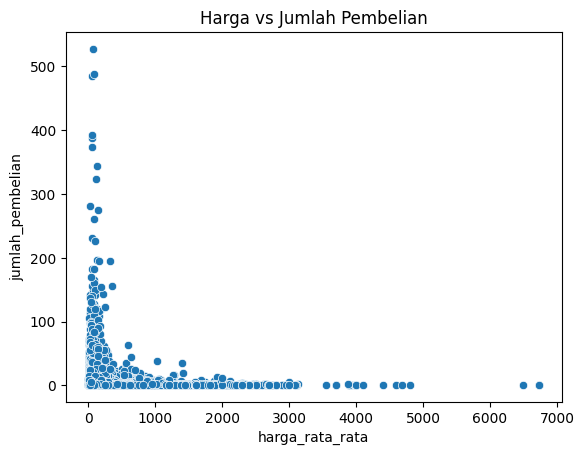

In [129]:
sns.scatterplot(x='harga_rata_rata', y='jumlah_pembelian', data=sales)
plt.title('Harga vs Jumlah Pembelian')
plt.show()

In [130]:
corr, _ = pearsonr(sales['harga_rata_rata'], sales['jumlah_pembelian'])
print("Korelasi:", corr)

Korelasi: -0.03213986268094517


**Insight:** (Opsional)
- Hasil analisis menunjukkan bahwa harga memiliki hubungan negatif terhadap jumlah pembelian, di mana produk dengan harga lebih rendah cenderung lebih banyak dibeli. Namun, tingkat korelasinya relatif lemah sehingga menunjukkan bahwa pelanggan tidak sepenuhnya sensitif terhadap harga. Hal ini mengindikasikan bahwa selain harga, terdapat faktor lain seperti kualitas produk, ulasan, dan pengalaman belanja yang juga memengaruhi keputusan pembelian.

### Pertanyaan 2:

In [131]:
review_product = df_review.groupby('product_id').agg({
    'review_score': 'mean'
}).reset_index()

worst_products = review_product.sort_values(by='review_score').head(10)

In [132]:
review_category = df_review.groupby('product_category_name').agg({
    'review_score': 'mean'
}).reset_index().sort_values(by='review_score')

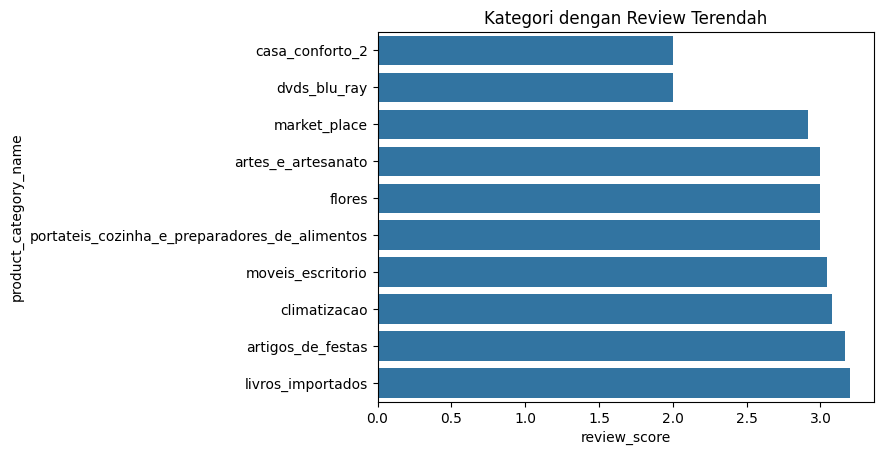

In [133]:
sns.barplot(x='review_score', y='product_category_name', data=review_category.head(10))
plt.title('Kategori dengan Review Terendah')
plt.show()

**Insight:** (Opsional)
- Analisis menunjukkan bahwa beberapa produk atau kategori tertentu cenderung mendapatkan review rendah, yang kemungkinan disebabkan oleh kualitas produk yang kurang sesuai dengan ekspektasi pelanggan. Selain itu, faktor lain seperti keterlambatan pengiriman, ketidaksesuaian deskripsi produk, serta pengalaman layanan juga turut memengaruhi tingkat kepuasan pelanggan. Oleh karena itu, peningkatan kualitas produk dan layanan menjadi kunci utama dalam meningkatkan rating dan loyalitas pelanggan.

## Analisis Lanjutan (Opsional)

In [134]:
rfm_df = orders.merge(orders_item, on='order_id')
rfm_df['order_purchase_timestamp'] = pd.to_datetime(rfm_df['order_purchase_timestamp'])

In [135]:
snapshot_date = rfm_df['order_purchase_timestamp'].max()

In [136]:
rfm = rfm_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'price': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print("\nRFM Data:")
print(rfm.head())


RFM Data:
                        customer_id  recency  frequency  monetary
0  00012a2ce6f8dcda20d059ce98491703      292          1     89.80
1  000161a058600d5901f007fab4c27140      413          1     54.90
2  0001fd6190edaaf884bcaf3d49edf079      551          1    179.99
3  0002414f95344307404f0ace7a26f1d5      382          1    149.90
4  000379cdec625522490c315e70c7a9fb      153          1     93.00


In [137]:
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4])

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [138]:
def segment(row):
    if row['R_score'] == 4 and row['F_score'] == 4 and row['M_score'] == 4:
        return 'Best Customers'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] == 4:
        return 'Recent Customers'
    elif row['F_score'] == 4:
        return 'Frequent Customers'
    else:
        return 'At Risk'

rfm['segment'] = rfm.apply(segment, axis=1)

print("\nSegment Distribution:")
print(rfm['segment'].value_counts())


Segment Distribution:
segment
At Risk               49209
Loyal Customers       22693
Recent Customers      12481
Frequent Customers    12300
Best Customers         1983
Name: count, dtype: int64


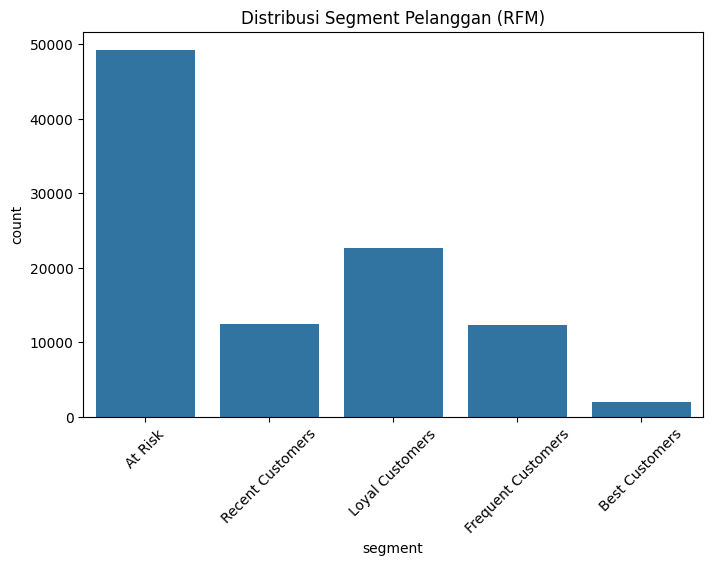

In [139]:
plt.figure(figsize=(8,5))
sns.countplot(x='segment', data=rfm)
plt.xticks(rotation=45)
plt.title('Distribusi Segment Pelanggan (RFM)')
plt.show()

In [140]:
print("\nINSIGHT:")

total_customer = len(rfm)
best = len(rfm[rfm['segment'] == 'Best Customers'])
at_risk = len(rfm[rfm['segment'] == 'At Risk'])

print(f"- Total Customer: {total_customer}")
print(f"- Best Customers: {best} ({best/total_customer:.2%})")
print(f"- At Risk Customers: {at_risk} ({at_risk/total_customer:.2%})")

if at_risk > best:
    print("- Banyak customer berisiko churn → perlu strategi retensi")
else:
    print("- Customer loyal cukup tinggi → pertahankan dengan loyalty program")


INSIGHT:
- Total Customer: 98666
- Best Customers: 1983 (2.01%)
- At Risk Customers: 49209 (49.87%)
- Banyak customer berisiko churn → perlu strategi retensi


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**
  - Harga produk memiliki pengaruh terhadap jumlah pembelian dengan kecenderungan hubungan negatif, di mana harga yang lebih rendah mendorong peningkatan jumlah pembelian. Namun, pengaruh tersebut tidak terlalu kuat sehingga menunjukkan bahwa pelanggan tidak sepenuhnya sensitif terhadap harga. Faktor lain seperti kualitas produk dan pengalaman belanja juga berperan penting dalam keputusan pembelian.
- **Conclusion pertanyaan 2:**
  - Beberapa produk atau kategori cenderung mendapatkan review rendah yang dipengaruhi oleh kualitas produk yang tidak sesuai ekspektasi, keterlambatan pengiriman, serta kurangnya kejelasan informasi produk. Hal ini menunjukkan bahwa kepuasan pelanggan tidak hanya ditentukan oleh produk itu sendiri, tetapi juga oleh keseluruhan pengalaman setelah pembelian.

**Rekomendasi Action Item:**
- Mengoptimalkan strategi harga seperti diskon atau bundling untuk meningkatkan jumlah pembelian
- Meningkatkan kualitas produk dan memastikan kesesuaian dengan deskripsi
- Memperbaiki sistem logistik untuk mengurangi keterlambatan pengiriman
- Memanfaatkan ulasan pelanggan sebagai bahan evaluasi produk dan layanan
- Menerapkan program loyalitas untuk meningkatkan retensi pelanggan

In [141]:
# contoh alur lengkap
import pandas as pd

orders = pd.read_csv('/content/data_1.csv')
order_items = pd.read_csv('/content/data_2.csv')
products = pd.read_csv('/content/data_3.csv')
reviews = pd.read_csv('/content/data_4.csv')

# merge
main_data = order_items.merge(orders, on='order_id')
main_data = main_data.merge(products, on='product_id')
main_data = main_data.merge(reviews, on='order_id')

# simpan
main_data.to_csv('main_data.csv', index=False)